In [1]:
import fwiVis.fwiVis as fv
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re
import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from geocube.api.core import make_geocube
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
from folium import plugins
import datetime
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 

## Weather Stations against Historic Mean

It's useful to compare the FWI or other station data against historic conditions. Below are some functions and helper-objects for accessing the station network.

Searching for availible stations athttps://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI
Plotting most-recent year and seasons:[5, 6, 7, 8, 9, 10]


/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:481: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  upper = mj.groupby([mj.index.day, mj.index.month]).quantile((1-0.025), numeric_only=True)
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:486: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  lower = mj.groupby([mj.index.day, mj.index.month]).quantile(0.025, numeric_only=True)
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:492: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before callin

Plotting most-recent year and seasons:[5, 6, 7, 8, 9, 10]


/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:481: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  upper = mj.groupby([mj.index.day, mj.index.month]).quantile((1-0.025), numeric_only=True)
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:486: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  lower = mj.groupby([mj.index.day, mj.index.month]).quantile(0.025, numeric_only=True)
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:492: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before callin

Plotting most-recent year and seasons:[5, 6, 7, 8, 9, 10]


/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:481: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  upper = mj.groupby([mj.index.day, mj.index.month]).quantile((1-0.025), numeric_only=True)
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:486: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  lower = mj.groupby([mj.index.day, mj.index.month]).quantile(0.025, numeric_only=True)
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:492: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before callin

Plotting most-recent year and seasons:[5, 6, 7, 8, 9, 10]


/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:481: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  upper = mj.groupby([mj.index.day, mj.index.month]).quantile((1-0.025), numeric_only=True)
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:486: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  lower = mj.groupby([mj.index.day, mj.index.month]).quantile(0.025, numeric_only=True)
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:492: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before callin

Plotting most-recent year and seasons:[5, 6, 7, 8, 9, 10]


/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:481: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  upper = mj.groupby([mj.index.day, mj.index.month]).quantile((1-0.025), numeric_only=True)
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:486: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before calling quantile instead.
  lower = mj.groupby([mj.index.day, mj.index.month]).quantile(0.025, numeric_only=True)
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:492: FutureWarning: Allowing bool dtype in DataFrameGroupBy.quantile is deprecated and will raise in a future version, matching the Series/DataFrame behavior. Cast to uint8 dtype before callin

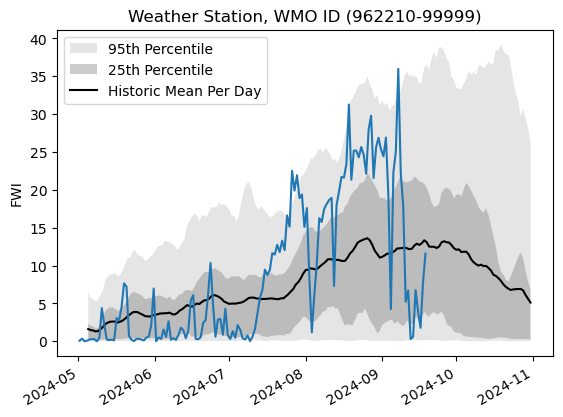

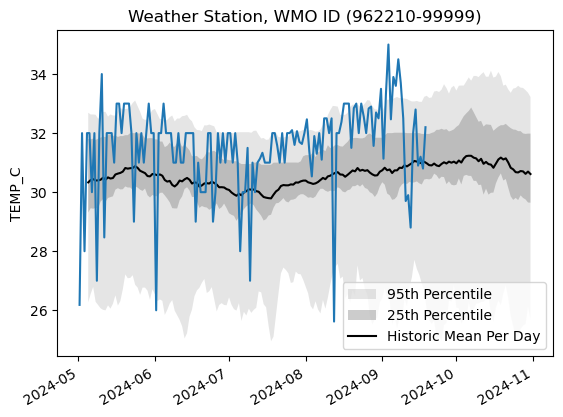

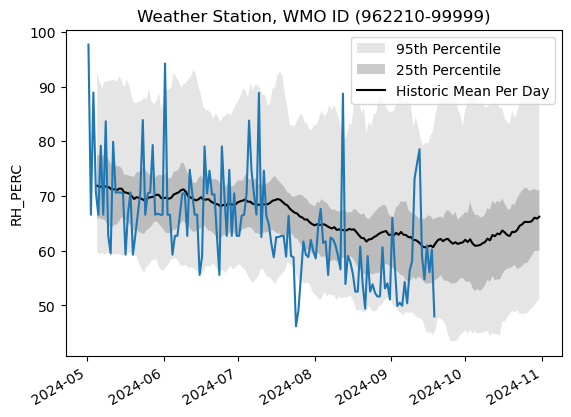

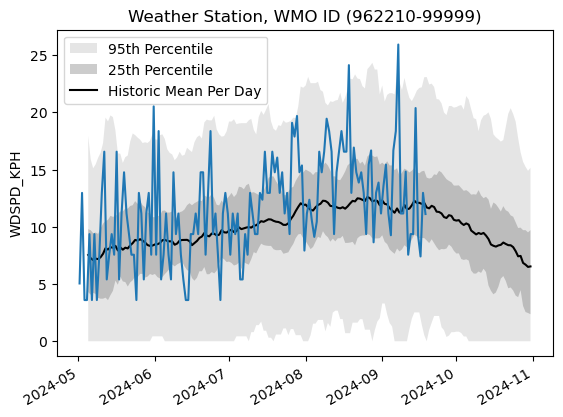

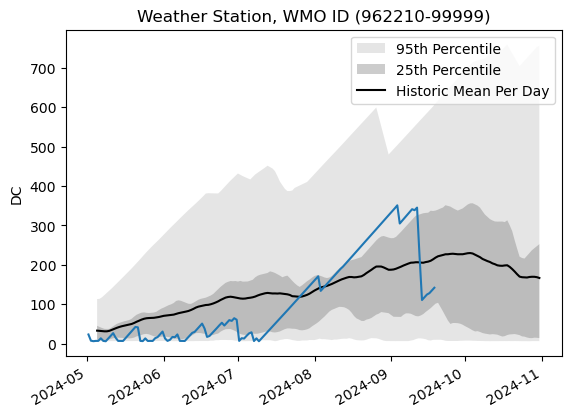

In [3]:
## Helper objects. These correspond to the paths where Non-US stations are stored. For CONUS-station helper objects, see below. 


files = fv.listFD("https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI", "csv") # This will update through time. Not nessisary now because focus on 2019
st_id_map = pd.read_csv('https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/isd-history.csv')

stations = fv.st_avail(files, st_id_map, path_s3 = "https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI", https_path = True)
st_dict = stations[['Lat', 'Lon']].to_dict('records')

vars = ['FWI', 'TEMP_C', 'RH_PERC', 'WDSPD_KPH', 'DC']
for var in vars: 
    #fv.plot_st_history(st_id_map, st_dict, stations, lat_lon=coords,  plot_var = var)
    fv.plot_st_history(st_id_map = st_id_map, st_dict = st_dict, stations = stations, USAF_WBAN = ['962210', '99999'],seasons=[5,6,7,8,9,10],plot_var= var, https_path =True)
    
    

In [22]:
mj = tmp
mj.index.day.unique()

mj

,YYYY,MM,DD,TEMP_C,RH_PERC,VPD_HPA,WDSPD_KPH,PREC_MM,SNOWDEPTH_M,VIS_KM,...,FWI,DSR,OBSMINUTEDIFF_TEMP,OBSMINUTEDIFF_RH,OBSMINUTEDIFF_WDSPD,PRECREPORTINGHOURS,OBSMINUTEDIFF_SNOW,HH,HH_format,isinseason
time,,,,,,,,,,,,,,,,,,,,,
1990-05-01 12:00:00,1990,5,1,29.400000,79.596969,8.363237,2.400000,2.787500,0,11.333333,...,0.360351,0.004467,120.0,120.0,120.0,24,120.0,12,12,True
1990-05-02 12:00:00,1990,5,2,28.633333,76.046888,9.423676,0.000000,2.375000,0,12.000000,...,0.178005,0.001282,480.0,480.0,480.0,22,480.0,12,12,True
1990-05-03 12:00:00,1990,5,3,26.466667,86.698658,4.703800,6.967059,0.000000,0,8.470588,...,0.519814,0.008543,2820.0,2820.0,2820.0,12,2820.0,12,12,True
1990-05-04 12:00:00,1990,5,4,28.066667,77.428696,8.955879,3.409412,0.000000,0,11.294118,...,0.711977,0.014908,1680.0,1680.0,1680.0,0,1680.0,12,12,True
1990-05-05 12:00:00,1990,5,5,29.900000,67.551579,13.721968,2.160000,0.000000,0,14.000000,...,2.158815,0.106201,300.0,300.0,300.0,8,300.0,12,12,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-27 12:00:00,2024,7,27,32.233333,60.254260,19.202525,14.760000,0.000000,0,10.000000,...,11.307453,1.990786,120.0,120.0,120.0,5,120.0,12,12,True
2024-07-28 12:00:00,2024,7,28,32.200000,59.828031,19.318487,9.960000,0.000000,0,10.000000,...,9.844693,1.557890,120.0,120.0,120.0,19,120.0,12,12,True
2024-07-29 12:00:00,2024,7,29,31.600000,60.821768,18.264934,12.360000,0.000000,0,10.000000,...,11.495132,2.049645,120.0,120.0,120.0,0,120.0,12,12,True


In [30]:
mean_quant = mj.groupby([mj.index.day.astype("str"), mj.index.month.astype("str")]).mean(numeric_only=True) ## Min and max both work. Why?
mean_quant

YYYY   MM    DD     TEMP_C    RH_PERC    VPD_HPA  WDSPD_KPH  \
time time                                                                  
1    5     2007.0  5.0   1.0  29.573947  74.716167  11.155419   5.489173   
     6     2007.0  6.0   1.0  30.279354  70.641271  13.116356   7.216540   
     7     2007.0  7.0   1.0  29.648392  69.307065  13.189029   6.516343   
10   5     2007.0  5.0  10.0  29.901977  73.164876  12.024592   6.792953   
     6     2007.0  6.0  10.0  29.757296  72.030258  12.240429   6.076816   
...           ...  ...   ...        ...        ...        ...        ...   
8    6     2007.0  6.0   8.0  29.665606  73.018408  11.908728   5.761991   
     7     2007.0  7.0   8.0  29.176222  70.439655  12.661478   7.588914   
9    5     2007.0  5.0   9.0  29.893537  72.789122  12.090351   5.913743   
     6     2007.0  6.0   9.0  29.607596  73.023404  11.900472   6.156832   
     7     2007.0  7.0   9.0  29.292619  69.517693  13.038990   7.756286   

             PREC_MM  SNOWDEPTH_M    VIS_KM  ...        BUI       ISI  \
time time                                    ...                        
1    5      9.106190          0.0  9.356396  ...   7.384801  1.137367   
     6      4.182976          0.0  9.699300  ...  15.576993  2.325429   
     7      6.972381          0.0  9.772381  ...  23.838858  2.179083   
10   5     16.582976          0.0  9.491555  ...   9.141516  1.397337   
     6      5.412024          0.0  9.691579  ...  15.392290  1.650769   
...              ...          ...       ...  ...        ...       ...   
8    6      5.180238          0.0  9.407028  ...  14.503845  1.331225   
     7      5.519524          0.0  9.351111  ...  21.927324  2.636954   
9    5      9.260476          0.0  9.664367  ...   9.795493  1.354229   
     6      9.338095          0.0  9.592161  ...  14.720460  1.435301   
     7      8.192857          0.0  9.248571  ...  22.711262  2.479415   

                FWI       DSR  OBSMINUTEDIFF_TEMP  OBSMINUTEDIFF_RH  \
time time                                                             
1    5     1.092326  0.073564         2734.285714       2734.285714   
     6     3.657829  0.567217         3380.571429       3380.571429   
     7     3.636578  0.455105          258.857143        258.857143   
10   5     1.672228  0.167352         2478.857143       2478.857143   
     6     2.657139  0.389594         3889.714286       3889.714286   
...             ...       ...                 ...               ...   
8    6     2.232971  0.372688         3929.142857       3929.142857   
     7     4.935306  0.883937          157.714286        157.714286   
9    5     1.662346  0.151975         2460.000000       2460.000000   
     6     2.254008  0.312905         3898.285714       3898.285714   
     7     4.545357  0.684644          183.428571        183.428571   

           OBSMINUTEDIFF_WDSPD  PRECREPORTINGHOURS  OBSMINUTEDIFF_SNOW  \
time time                                                                
1    5             2734.285714           13.742857         2734.285714   
     6             3380.571429           12.742857         3380.571429   
     7              262.285714           12.571429          253.714286   
10   5             2473.714286           16.657143         2473.714286   
     6             3925.714286           13.057143         3889.714286   
...                        ...                 ...                 ...   
8    6             3965.142857           15.457143         3929.142857   
     7              154.285714           11.371429          154.285714   
9    5             2460.000000           14.285714         2460.000000   
     6             3934.285714           13.857143         3898.285714   
     7              183.428571           12.914286          183.428571   

           isinseason  
time time              
1    5            1.0  
     6            1.0  
     7            1.0  
10   5            1.0  
     6            1.0  
...               .

The function that plots station data against a historical mean is called `plot_st_history`. `plot_st_history` is fairly flexible. It allows you to choose a station according to either a known path, a USAF_WBAN id, or a lat lon. You can access my pre-built functions by typing `fv.{functionname}` like so:

In [23]:
import requests
from bs4 import BeautifulSoup

def listFD(url, ext=''):
    '''
    NCCS retrival helper functions for getting gridded data
    '''
    page = requests.get(url).text
    #print(page)
    soup = BeautifulSoup(page, 'html.parser')
    return [url + '/' + node.get('href') for node in soup.find_all('a') if node.get('href').endswith(ext)]

inter_type = "linear.HourlyFWIFromHourlyInterpContinuous"

path_s3 = "https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI/"
file_inter = []
for file in listFD(path_s3, "csv"):
    file_inter.append(file)

for i in file_inter:
    pt_1 = re.sub(path_s3, "", i)
    #pt_2 = re.sub(".spline.DailyFWIfromHourlyInterp.csv","",  pt_1)
    pt_2 = re.sub(("." + inter_type + ".csv"), "", pt_1)
    pt_3 = pt_2.split("/FWI/")
    pt_4 = re.sub("/", "", pt_3[0])
    pt_5 = pt_4.split("-")
    usaf = re.sub(r'[^0-9]', '',pt_5[0]) ## Sometimes ID had extra characters? 
    wban = re.sub(r'[^0-9]', '',pt_5[1]) 
    
    

In [24]:
wban

'99999'

In [11]:
USAF_WBAN = ['966550', '99999']
stations.loc[(stations.USAF == USAF_WBAN[0]) & (stations.WBAN == USAF_WBAN[1])]

,File_path,Lat,Lon,USAF,WBAN
129,https://portal.nccs.nasa.gov/datashare/GlobalF...,-2.233,113.95,966550,99999


By default, this function will plot FWI. 

In [6]:
files

['veda-data-store-staging/EIS/other/station-FWI/19900101.NRT/FWI/166270-99999.19900101.FWI_DC.png',
 'veda-data-store-staging/EIS/other/station-FWI/19900101.NRT/FWI/166270-99999.19900101.PREC_RH_QUAL.png',
 'veda-data-store-staging/EIS/other/station-FWI/19900101.NRT/FWI/166270-99999.20230101.FWI_DC.png',
 'veda-data-store-staging/EIS/other/station-FWI/19900101.NRT/FWI/166270-99999.last-21days.FWI_DC.png',
 'veda-data-store-staging/EIS/other/station-FWI/19900101.NRT/FWI/166270-99999.last-21days.Visibility.png',
 'veda-data-store-staging/EIS/other/station-FWI/19900101.NRT/FWI/166270-99999.linear.DailyFWIfromHourlyInterp.csv',
 'veda-data-store-staging/EIS/other/station-FWI/19900101.NRT/FWI/166270-99999.linear.HourlyFWIFromHourlyInterpContinuous.csv',
 'veda-data-store-staging/EIS/other/station-FWI/19900101.NRT/FWI/166990-99999.19900101.FWI_DC.png',
 'veda-data-store-staging/EIS/other/station-FWI/19900101.NRT/FWI/166990-99999.19900101.PREC_RH_QUAL.png',
 'veda-data-store-staging/EIS/other

In [8]:
fv.plot_st_history(st_id_map = st_id_map, st_dict = st_dict, stations = stations, USAF_WBAN = ['966550', '99999'],seasons=[5,6,7],plot_var='FWI')

Plotting most-recent year and seasons:[5, 6, 7]


TypeError: agg function failed [how->mean,dtype->object]

But it can also plot any of the data assosiated with the stations. It can also search for the closes station to a given lat lon. 

In [7]:
fv.plot_st_history(st_id_map = st_id_map, st_dict = st_dict, stations = stations, lat_lon = [50.52, -72.768], plot_var = 'TEMP_C')

/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:192: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hav = 0.5 - cos((lat2-lat1)*p)/2 + cos(lat1*p)*cos(lat2*p) * (1-cos((lon2-lon1)*p)) / 2


The closest station is 150.48059588581046 km away.
Plotting most-recent year and seasons:[5, 6, 7]


TypeError: agg function failed [how->mean,dtype->object]

# Station plotting functions

Here is the raw code I used to define the functions above, which may be useful if you would like to make fixed or tweaks to the functions. They should work the same way as the `fv.{fucntion_name}`, but without the `fv`. 

In [28]:
def distance(lat1, lon1, lat2, lon2):
    '''
    Finds distance in km between two points designated with lat and lon values 
    
    INPUTS:
        
        lat1 (str):  A  lattitude
        lon1 (str):  A longitude
        lat2 (str):  second lattitude
        lon2 (str):  second longitude 
    
    '''
    p = 0.017453292519943295
    hav = 0.5 - cos((lat2-lat1)*p)/2 + cos(lat1*p)*cos(lat2*p) * (1-cos((lon2-lon1)*p)) / 2
    return 12742 * asin(sqrt(hav)) ## Returns in km

def closest(data, v):
    '''
    Will return the shortests distance between one lat/lon point and a dictionary of several lat/lon points. 
    
    INPUTS:
        
        data (dict):  A  dictionary with "Lat" and "Lon" entries to compare to v
        v (dict):  A dictinary with a single "Lat" and "Lon" entry. 
    
    '''
    mn = min(data, key=lambda p: distance(v['Lat'],v['Lon'],p['Lat'],p['Lon']))
    dist = distance(v['Lat'],v['Lon'], mn['Lat'], mn['Lon'])
    #this_station = data[(data['Lat'] == mn['Lat']) & (data['Lon'] == mn['Lon'])]
    #print("The closest station is", this_station["STATION NAME"]," USAF: ", this_station["USAF"],"located at Lat", mn['Lat']," and Lon",mn['Lon'],  "and is ",  dist, "km away." )
    print("The closest station is",  dist, "km away." )
    return mn

def date_convert(dat_time):
    '''
    Takes a data frame with the columns "YYYY", "MM", "DD", and "HH" and converts those columns into a single datetime column. 
    
    INPUTS:
        
        dat_time (DataFrame):  A data frame with the columns "YYYY", "MM", "DD", and "HH". Hours do not have leading zeros. 
    
    '''
    dat_time.HH = dat_time.HH.astype('int') # Drop #.0
    dat_time.HH = dat_time.HH.astype('str')
    dat_time['HH_format'] = dat_time.HH.apply(hour_fix)
    dat_time['time'] = pd.to_datetime(dat_time['YYYY'].astype(str) +"-"+  dat_time['MM'].astype("str") +"-"+  dat_time['DD'].astype("str") + " " + dat_time['HH_format'].astype('str'), format='%Y-%m-%d %H')

    return(dat_time)

def hour_fix (hr):
    '''
    Appends a leading 0 to hours for date formatting 
    
    INPUTS:
        
        hr (str): An hour digit from 0-24
    
    '''
    small_hr = ["0","1","2","3","4","5","6","7","8","9"]
    append = ""
    
    if (hr in small_hr):
        append = "0"
    hr = append + hr
    
    return(hr)

def plot_st_history(st_id_map, st_dict, stations, title = None, path = None, lat_lon = None, USAF_WBAN = None, seasons = [5, 6, 7], year = None, plot_var = "FWI", clim_normal_min = datetime.datetime(1991, 1, 1), 
    clim_normal_max = datetime.datetime(2020, 12, 31)):
    '''
    Plots weather station data against historic means. Stations can be plotted form a file path, an USAF_WBAN id, or a lat and lon combination. If no station is at the exact lat lon, the function will search for the closest one. 
    
    INPUTS:
        st_dict (dict): A  dictionary with "Lat" and "Lon" entries for each weather station. A dictionary of the output from st_avail.
        stations (DataFrame): a dataframe as outputted by st_avail. A dataframe with columns for station lat, lon, and ID.
        st_id_map (DataFrame): a dataframe that connects Station IDs to full names and locations. 
        title (str):  An optional title for the plot. Optional. "None" is default. If "None", title will be the WMO ID of the station. 
        path (str):  Path to staion data csv. Optional. Default to "None". 
        lat_lon (list): A list of the form [lat_float, lon_float]. Optional. If lat and lon are not exact matches, function will search for closest station. 
        USAF_WBAN (list): List of the form [USAF, WBAN]. Optional. 
        seasons (list): List with single-digit representations of months to include in averaging across years. Default [5, 6, 7] or May, June and July. 
        year (str): The year of station data to compare to historic means. Defaults to "None", where the most recent data will be compared.
        plot_var (str): Variable to plot. Defaults to "FWI". 
        clim_normal_min (datetime): minimum period for climate normal. Defaults to January 1, 1991. If station data doesn not extend as far back as minimum, normal will be on min of station data and will throw a warning. 
        clim_normal_max (datetime): Maximum period for climate normal. Defaults to December 31st, 2020. If station data doesn not extend into maximum, normal will be on max of station data and will throw a warning. 
    '''
    
    if(all([path == None, lat_lon == None, USAF_WBAN == None])):
        print("Error: No specifying information provided. Please include a path to station, a lat-lon, or a USAF_WBAN id. ")
    if(path == None):
        if( not USAF_WBAN == None ):
            st = stations.loc[(stations.USAF == USAF_WBAN[0]) & (stations.WBAN == USAF_WBAN[1])]
            path = "s3://" + st.File_path.iloc[0]
        else:
            st = stations.loc[(stations.Lat == lat_lon[0]) & (stations.Lon== lat_lon[1])]
            if(len(st) == 0):
                st_cls = closest(st_dict, pd.DataFrame(data = {"Lat" :[lat_lon[0]], "Lon" :  [lat_lon[1]]}))
                st = stations.loc[(stations.Lat == st_cls["Lat"]) & (stations.Lon == st_cls["Lon"])]
                
            path = "s3://" + st.File_path.iloc[0]
    
    if(title == None):
        split = re.split(pattern = "/", string = path)
        split = split[-1]
        WMO_id = re.sub(pattern = "\..*", repl = "",  string = split)
        extra = ""
        if("s3://" in path):  
            id_split = re.split(pattern = "-", string = WMO_id)
            labs = st_id_map[(st_id_map.USAF == str(id_split[0])) & (st_id_map.WBAN == str(id_split[1]))]
            extra = str(*labs['STATION NAME'])  + str(*labs['CTRY'])+ ", " + str(*labs['STATE'])
        title = "Weather Station" + extra +  "WMO ID (" + WMO_id + ")"


    st = pd.read_csv(path)
    if(not np.any(st.columns.isin(["HH"]))):
         st['HH'] = '12'
    st.YYYY = st.YYYY.astype("int")
    st.MM = st.MM.astype("int")
    st.DD = st.DD.astype("int")
    st.HH = st.HH.astype("int")
    st = date_convert(st)
    
    max_season = max(seasons)
    if(max_season <= 9):
        max_season = "0" + str(max_season)
    min_season = min(seasons)
    if(min_season <= 9):
        min_season = "0" + str(min_season)
    min_season = str(min_season)
    max_season = str(max_season)
    
    if(year == None):
        print("Plotting most-recent year and seasons:" + str(seasons))
        #ctime = datetime.datetime.now()
        #year = str(ctime.year)
        year = str(max(st.time.dt.year))
    else:
        year = year
    
    max_day = year + "-" + max_season + "-28 23:00:00" ## Hack
    min_day = year + "-" + min_season + "-01 00:00:00"
        

    st['isinseason'] = st.MM.isin(seasons) # Is May, June or July? 
    mj = st[st['isinseason'] == True]
    mj = mj.set_index("time")
    

    # Try to use 1991-2020, or user supplied range as climate normal. If not possible, get as close as you can.     
    if((min(st.time) > clim_normal_min) |  (max(st.time) < clim_normal_max)):
        print("WARNING: Station record does not cover assumed climate normal (1991-2020).")
        print("Using range " + str(max(clim_normal_min, min(st.time))) + ":" + str(min(clim_normal_max, max(st.time))) + " instead.")
        mj = mj[mj.index > max(clim_normal_min, min(st.time))]
        mj = mj[mj.index < min(clim_normal_max, max(st.time))]
    
    mj = mj[mj.index.strftime('%m-%d') != '02-29'] # Drop leap-day becuase it's only sampled once every 4 years

    mean_quant = mj.groupby([mj.index.day, mj.index.month]).mean()

    dates = ( year + "-" + mean_quant.index.get_level_values(level=1).astype("str") + "-" + mean_quant.index.get_level_values(level=0).astype("str"))

    mean_quant["dates"] = pd.to_datetime(dates)
    mean_quant = mean_quant.sort_values(by = "dates")
    mean_quant.set_index("dates", inplace = True)


    upper = mj.groupby([mj.index.day, mj.index.month]).quantile((1-0.025))
    upper["dates"] = pd.to_datetime(dates)
    upper = upper.sort_values(by = "dates")
    upper.set_index("dates", inplace = True)

    lower = mj.groupby([mj.index.day, mj.index.month]).quantile(0.025)
    lower["dates"] = pd.to_datetime(dates)
    lower = lower.sort_values(by = "dates")
    lower.set_index("dates", inplace = True)


    mid_lower = mj.groupby([mj.index.day, mj.index.month]).quantile(0.25)
    mid_lower["dates"] = pd.to_datetime(dates)
    mid_lower = mid_lower.sort_values(by = "dates")
    mid_lower.set_index("dates", inplace = True)


    mid_upper = mj.groupby([mj.index.day, mj.index.month]).quantile(0.75)
    mid_upper["dates"] = pd.to_datetime(dates)
    mid_upper = mid_upper.sort_values(by = "dates")
    mid_upper.set_index("dates", inplace = True)
    
    st = st.sort_values(by = ["time"])
    try:
        upper[plot_var].rolling(5).mean()
    except:
        print("print_var is not present in this weather station. Columns are: " + str(st.columns))
        return(None)
    
    daily_vars = ["DC", "BUI", "DMC", "PREC_MM"] # Vars that are daily even with hourly station data
    
    fig, ax = plt.subplots()
    ax.fill_between(upper.index, upper[plot_var].rolling(5).mean(), lower[plot_var].rolling(5).mean(), 
                    facecolor='grey', 
                    alpha=0.2,
                    label= "95th Percentile")
    ax.fill_between(mid_upper.index, mid_upper[plot_var].rolling(5).mean(), mid_lower[plot_var].rolling(5).mean(), 
                    facecolor='grey', 
                    alpha=0.4,
                    label= "25th Percentile")
    ax.plot(mean_quant.index, mean_quant[plot_var].rolling(5).mean(), 
            color = "black",
            label= "Historic Mean Per Day")
    if(plot_var in daily_vars):
        tmp = st.dropna()
        ax.plot(tmp[(tmp.time >= min_day) & (tmp.time <= max_day)].time.astype('datetime64[ns]'), tmp[(tmp.time >= min_day) & (tmp.time <= max_day)][plot_var])
    else:
        ax.plot(st[(st.time >= min_day) & (st.time <= max_day)].time.astype('datetime64[ns]'), st[(st.time >= min_day) & (st.time <= max_day)][plot_var])
   
    ax.set_ylabel(plot_var)
    ax.set_title(title)
    ax.legend()
    fig.autofmt_xdate()
    return(st)



The closest station is 482.5032055472788 km away.
Plotting most-recent year and seasons:[5, 6, 7]


/tmp/ipykernel_836/665377173.py:165: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mean_quant = mj.groupby([mj.index.day, mj.index.month]).mean()
/tmp/ipykernel_836/665377173.py:174: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  upper = mj.groupby([mj.index.day, mj.index.month]).quantile((1-0.025))
/tmp/ipykernel_836/665377173.py:179: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  lower = mj.groupby([mj.index.d

UnboundLocalError: local variable 'lower_range' referenced before assignment

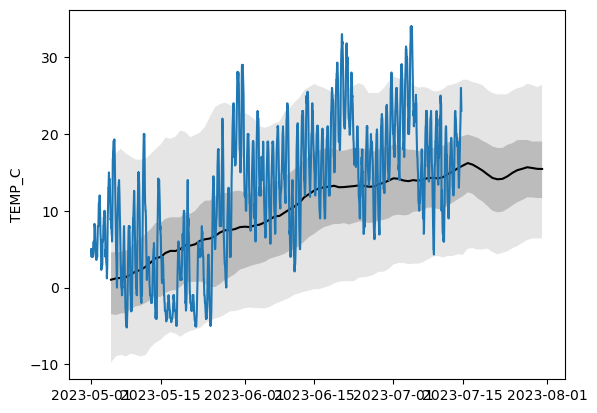

In [29]:
st = plot_st_history(st_id_map = st_id_map, st_dict = st_dict, stations = stations, lat_lon = [50.52, -72.768], plot_var = 'TEMP_C')